# Raw `.h5` --> cleaned `.npz`

This example takes a raw Maxwell recording and runs it through a customizable preprocessing pipeline then saves the
cleaned data as an `.npz` for later burst detection / analysis.

The moving parts:

- **`Config`** (`mxtreme.config`) — reads `mxtreme.toml` to find the *managed data store* (where outputs
  are written and later read back). Raw inputs are pointed at by explicit path.
- **`extract`** (`mxtreme.extract`) — raw `.h5` → per-well data dicts.
- **`clean`** (`mxtreme.clean`) — the composable cleaning functions.
- **`Pipeline`** (`mxtreme.pipeline`) — runs your chosen pipeline over every well.
- **`io`** (`mxtreme.io`) — read/write `.npz`and updates the registry.


> Run this notebook from the `examples/` directory so the relative paths resolve.

In [14]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [52]:
from functools import partial
from pathlib import Path

from mxtreme import extract
from mxtreme import clean
from mxtreme.pipeline import Pipeline
from mxtreme.config import Config
from mxtreme import io

### 1. Configure output directory

- Root path for saving MXtreme output including:
    - `preprocessed/` - houses cleaned .npz's


In [47]:
# The managed store (outputs) comes from the TOML — edit examples/mxtreme.toml to point elsewhere.
config = Config.from_toml("mxtreme.toml")
print("managed store root:", config.data_root.resolve())
print("preprocessed dir: ", config.preprocessed_dir.resolve())

managed store root: /Users/cgrass04/Code/mxtreme-dev/mxtreme-claude/claude_output
preprocessed dir:  /Users/cgrass04/Code/mxtreme-dev/mxtreme-claude/claude_output/preprocessed


### 2. Extract data from the raw .h5 recording

`extract()` looks for a metadata field in `/assay/metadata` inside the `.h5` containing (Exp ID / Chip ID / Plate date / DIV / Conditions). If it doesn't exist a metadata dict with this information must be passed into the function (see example below).

Conditions is an optional key.

```python
metadata = {"Exp ID": "May2025_Wave", "Chip ID": "M07459", "Plate date": 250512, "DIV": 0}
data = extract.extract(str(PATH_TO_RAW), metadata=metadata, wells=0)
```

In [80]:
RAW_ROOT = Path("../../mxtreme-claude/claude_data/raw")   # read-only example data


# Examples with embedded metadata
# RAW_H5 = RAW_ROOT / "Fall_BurstTrainer" / "M07140" / "111825_M07140_DIV33_burst_trainer.raw.h5"
# RAW_H5 = RAW_ROOT / "Fall_BurstTrainer" / "P004722" / "111825_P004722_DIV48_burstTrain.raw.h5"
# data = extract.extract(str(RAW_H5))          # embedded /assay/metadata read automatically

# Example with supplied metadata
metadata = {"Exp ID": "May2025_Wave", "Chip ID": "M07459", "Plate date": 250512, "DIV": 0, "Conditions":[[2,0]]}
RAW_H5 = RAW_ROOT / "May2025_Wave" / "M07459" / "250512" / "0" / "well0" / "May2025_Wave_well_0.raw.h5"
data = extract.extract(str(RAW_H5), metadata=metadata)

Extracting: May2025_Wave_well_0.raw.h5
  Metadata source : caller-supplied
  Conditions      : present
  Wells requested : all
------------------------------------------------------------
  well 0 | 4,633,386 spikes | condition [2, 0]
------------------------------------------------------------
Done: extracted 1 well(s) from May2025_Wave_well_0.raw.h5


### 3. Define the preprocessing pipeline

Pipeline assembles a list of preprocessing functions from `mxtreme.clean`. 

Use a bare function to accept its default parameters, or wrap it with `partial(...)` to override them. Pipeline executes in the order the functions are listed. 

In [81]:
pipeline = Pipeline([
    clean.normalize_time,                                     # frames -> start at 0
    clean.dac_to_voltage,                                     # DAC units -> V
    clean.remove_positive_deflections,                        # keep negative spikes
    partial(clean.spike_filter, amp_thresh=2e-5),             # drop < 20 µV  
    partial(clean.remove_spurious_spikes, refractory_period=0.002),
    clean.remove_spurious_channels,                           # drop unmapped channels
    clean.build_channel_map,                                  # needed before binning
    partial(clean.remove_stim_frames, post_stim_period=0.05), # drop stim-window spikes
    partial(clean.bin_spikes, bin_size=0.01),                 # 10 ms bins
])

### 4. Test the pipeline before saving data with `transform()` (Optional)

In [ ]:
# import copy # use a copy because transform modifies the data in place
# _ = pipeline.transform(copy.deepcopy(data))

### 5. Run the pipeline and save the cleaned `.npz`

Outputs are written under the managed store from your config. Each time a pipeline is executed a `registry.csv` located in the `data_root` is updated keeping track of which files have been extracted and cleaned and when. 

In [82]:
paths = pipeline.run(data, datastore=config.preprocessed_dir)

# Each saved well is recorded in registry.csv automatically (see mxtreme.io.save_preprocessed),
# with its experimental condition and a fresh timestamp.

paths

well 0 | normalize_time               4,633,386 -> 4,633,386 (+0.0%) 0.00s
well 0 | dac_to_voltage               4,633,386 -> 4,633,386 (+0.0%) 0.00s
well 0 | remove_positive_deflections  4,633,386 -> 1,992,954 (-57.0%) 0.01s
well 0 | spike_filter                 1,992,954 -> 1,984,843 (-0.4%) 0.00s
well 0 | remove_spurious_spikes       1,984,843 -> 1,920,012 (-3.3%) 0.15s
well 0 | remove_spurious_channels     1,920,012 -> 1,918,497 (-0.1%) 0.00s
well 0 | build_channel_map            1,918,497 -> 1,918,497 (+0.0%) 0.00s
well 0 | remove_stim_frames           1,918,497 -> 513,595 (-73.2%) 0.01s
well 0 | bin_spikes                   513,595 -> 513,595 (+0.0%) 0.04s
well 0 | biggest reducer: remove_positive_deflections removed 2,640,432 spikes 



[PosixPath('../../mxtreme-claude/claude_output/preprocessed/May2025_Wave/M07459/well0/DIV0_250512_M07459_May2025_Wave_well0_exp_data.npz')]

### 5. Reload the saved NPZ

Check the cleaned data loads back and that `preprocessing_params` record exactly which steps/params ran.

In [83]:
loaded = io.load_preprocessed(paths[0])
print("saved file:        ", paths[0])
print("spike_data shape:  ", loaded["spike_data"].shape)
print("channelmap shape:  ", loaded["channelmap"].shape)
print("spike_bin shape:   ", loaded["spike_bin"].shape)
print("samp_rate:         ", float(loaded["samp_rate"][0]))
print("bin_size (s):      ", float(loaded["bin_size"]))
print("preprocessing_params:", loaded["preprocessing_params"].item())

saved file:         ../../mxtreme-claude/claude_output/preprocessed/May2025_Wave/M07459/well0/DIV0_250512_M07459_May2025_Wave_well0_exp_data.npz
spike_data shape:   (513595,)
channelmap shape:   (1016, 5)
spike_bin shape:    (1016, 360083)
samp_rate:          10000.0
bin_size (s):       0.01
preprocessing_params: {'amp_thresh': 2e-05, 'refractory_period': 0.002, 'post_stim_period': 0.05, 'bin_size': 0.01}


## 5. Visualize the data

Three basic, analysis-free views of the raw data from `mxtreme.visualizations`:
- **ASDR** — array-wide spike detection rate over time (mean binned activity across channels).
- **Raster** — binned spikes, channels × time.
- **MEA map** — spatial layout of the electrodes (⚡ marks stimulation electrodes).

The ASDR + raster share an x-axis over a short window of bins so the structure is visible.

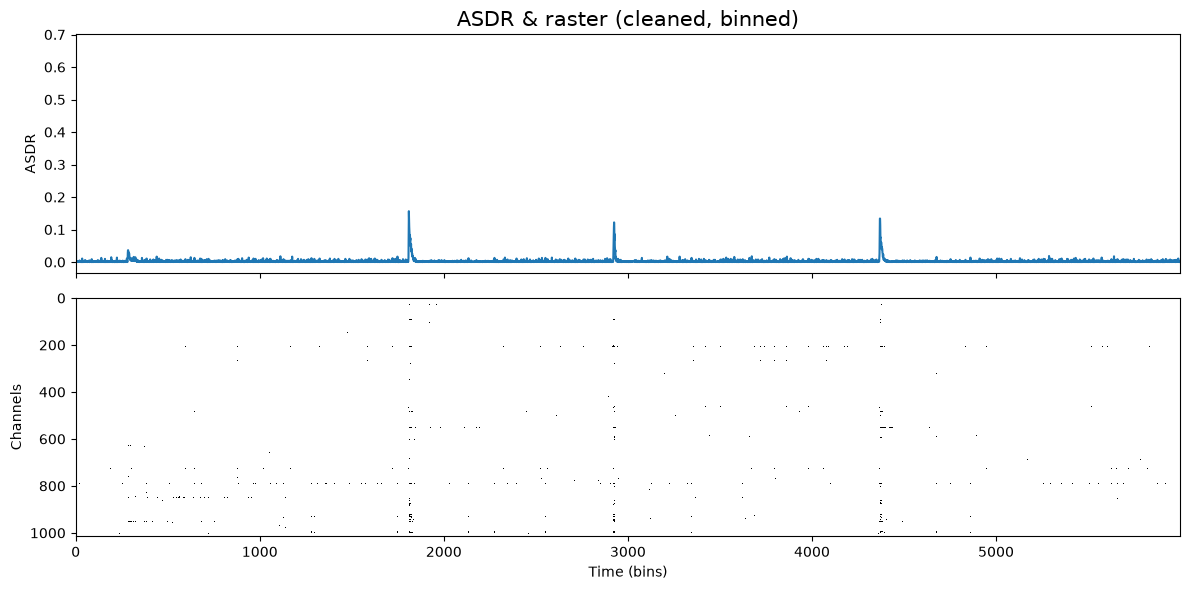

In [84]:
from mxtreme import visualizations as viz
import matplotlib.pyplot as plt

sb = loaded["spike_bin"]
win = (0, min(6000, sb.shape[1]))          # window of bins to display (10 ms bins) - first minute of the recording
sb_win = sb[:, win[0]:win[1]]


fig, (ax_asdr, ax_rast) = plt.subplots(2, 1, sharex=True, figsize=(12, 6))
viz.plot_asdr(sb_win, ax=ax_asdr, title="ASDR & raster (cleaned, binned)")
viz.raster(sb_win, ax=ax_rast)
ax_asdr.set_xlabel("")
plt.tight_layout()
plt.show()

In [85]:
# Spatial map of the electrodes on the MEA
stim = loaded["stim_elecs"]
stim = stim.item() if getattr(stim, "ndim", 1) == 0 else stim   # unwrap 0-d object array (may be None)
stim

array([ 4673, 21839,  4355, 19751])

Left: 421, Right: 595


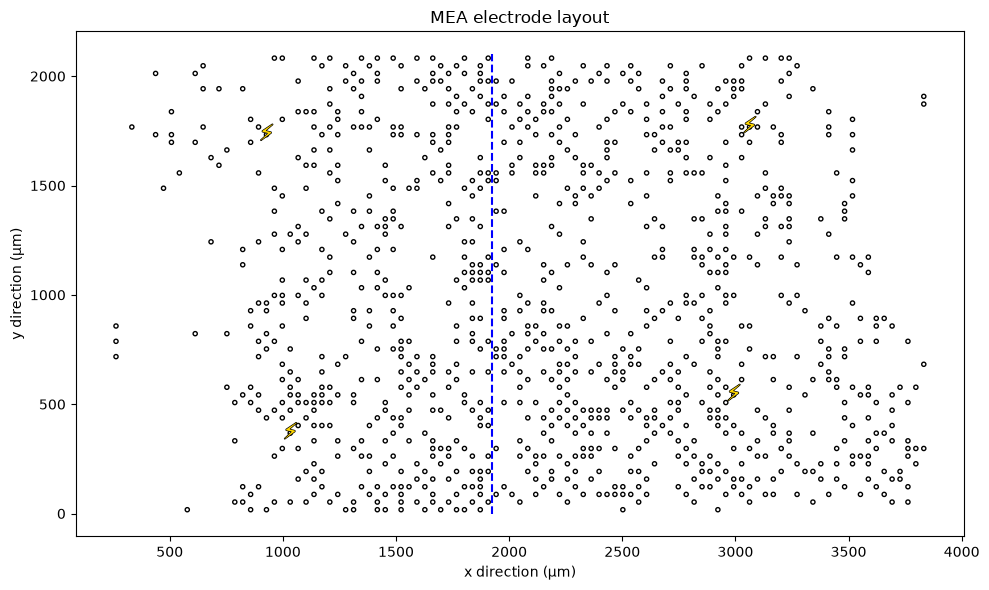

In [86]:
fig, ax = plt.subplots(1, 1, figsize=(10,6))
viz.MEA(ax, loaded["channelmap"], stim, title="MEA electrode layout")
plt.tight_layout()
plt.show()